# 03 - EDA

**Loads the fully merged OTP + GTFS dataset from `data/` and runs exploratory analysis.**

## Installs and imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASEPATH = "../data"

## Load Data

In [2]:
# Load from data/ -- output of 02b_gtfs_merge.ipynb
df_valid = pd.read_parquet(f"{BASEPATH}/2_df_gtfs_linked.parquet")
print(f"Loaded {len(df_valid):,} rows")

Loaded 20,131,404 rows


## Quick exploration

In [3]:
df_valid.head()

,service_date,time,train_number,lateness,datetime,year,month,day_of_week,period_flag,line,trip_id,direction_id,source_gtfs_date,sched_origin_sec,sched_terminus_sec,sched_duration_sec,n_scheduled_stops,origin_stop_id,terminus_stop_id
0,2017-01-01,00:00:00,3540,25,2017-01-02 00:00:00,2017,1,Sunday,normal,Lansdale/Doylestown,LAN_3540_V7_M,0,2016-12-16,79680.0,85080.0,5400.0,28.0,90406,90538
1,2017-01-01,00:00:00,3542,1,2017-01-02 00:00:00,2017,1,Sunday,normal,Lansdale/Doylestown,LAN_3542_V7_M,0,2016-12-16,83280.0,88680.0,5400.0,28.0,90406,90538
2,2017-01-01,00:00:00,5368,0,2017-01-02 00:00:00,2017,1,Sunday,normal,Paoli/Thorndale,PAO_5368_V7_M,0,2016-12-16,83820.0,86520.0,2700.0,19.0,90505,90004
3,2017-01-01,00:02:00,3540,23,2017-01-02 00:02:00,2017,1,Sunday,normal,Lansdale/Doylestown,LAN_3540_V7_M,0,2016-12-16,79680.0,85080.0,5400.0,28.0,90406,90538
4,2017-01-01,00:02:00,9740,0,2017-01-02 00:02:00,2017,1,Sunday,normal,Trenton,TRE_9740_V7_M,0,2016-12-16,86460.0,90000.0,3540.0,14.0,90701,90007


In [4]:
df_valid.dtypes 

service_date          datetime64[ms]
time                             str
train_number                     str
lateness                       int32
datetime              datetime64[us]
year                           int32
month                          int32
day_of_week                      str
period_flag                      str
line                             str
trip_id                          str
direction_id                     str
source_gtfs_date      datetime64[ns]
sched_origin_sec             float64
sched_terminus_sec           float64
sched_duration_sec           float64
n_scheduled_stops            float64
origin_stop_id                   str
terminus_stop_id                 str
dtype: object

In [5]:
# date range covered
print(f"Earliest date: {df_valid['service_date'].min().date()}")
print(f"Latest date:   {df_valid['service_date'].max().date()}")

Earliest date: 2017-01-01
Latest date:   2025-12-31


In [6]:
# basic stats on lateness
print(df_valid["lateness"].describe().apply(lambda x: f"{x:.2f}"))

count    20131404.00
mean            5.07
std             9.43
min             0.00
25%             1.00
50%             2.00
75%             5.00
max          1436.00
Name: lateness, dtype: str


## Lateness Distribution

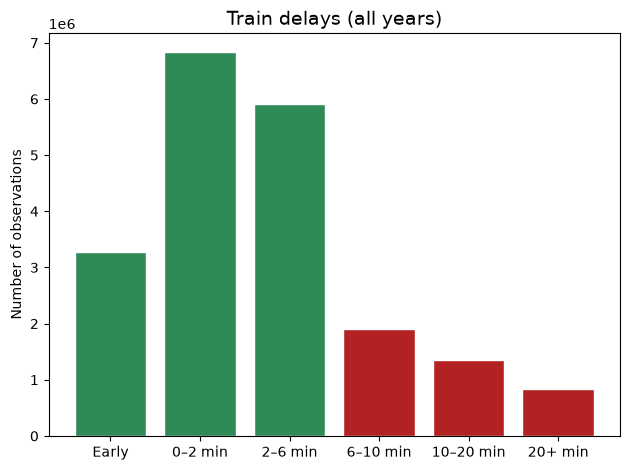

In [7]:
# How often are trains on time vs. late?

bins = [-999, 0, 2, 6, 10, 20, 998]
labels = ["Early", "0–2 min", "2–6 min",
          "6–10 min", "10–20 min", "20+ min"] # labels for plot

df_valid["lateness_bucket"] = pd.cut(df_valid["lateness"], bins = bins, labels = labels)

bucket_counts = df_valid["lateness_bucket"].value_counts().reindex(labels)

fig, ax = plt.subplots()
ax.bar(labels, bucket_counts,
       color = np.array(["seagreen"]*3 + ["firebrick"]*3),
       edgecolor = "white")
ax.set_title("Train delays (all years)", fontsize = 14)
ax.set_ylabel("Number of observations")
ax.set_xlabel("") # none
ax.set_xticks(range(len(labels)))
ax.tick_params(axis = "x", rotation = 0)
plt.tight_layout()
plt.show() # show plot

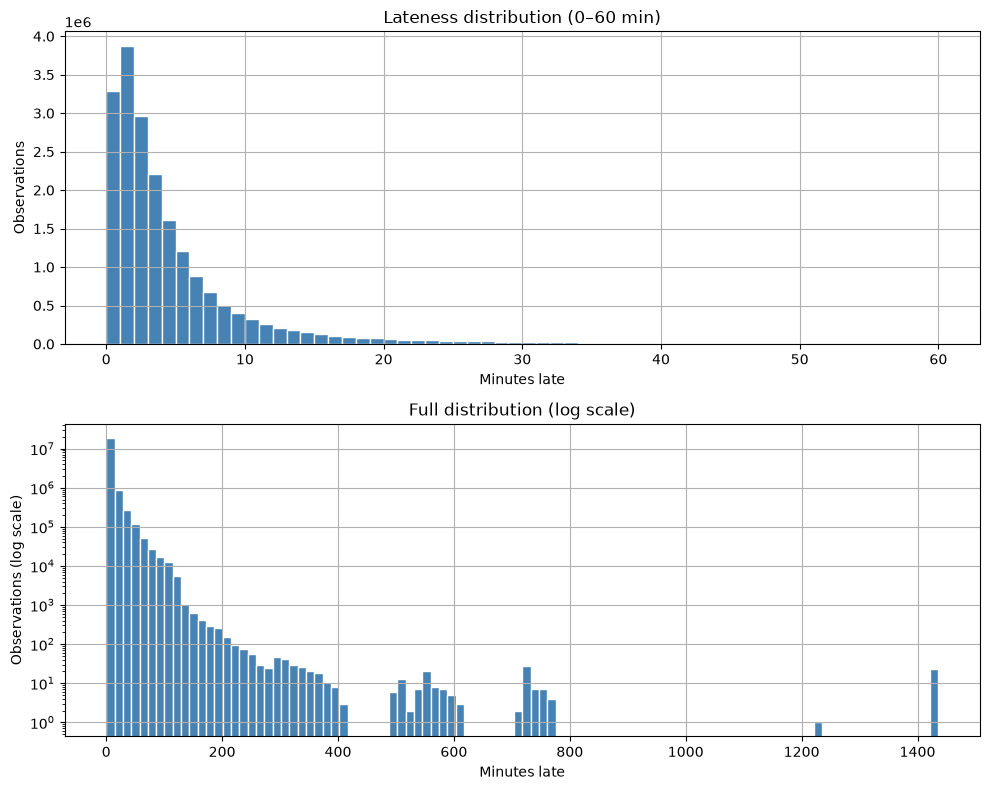

In [8]:
# Plotting distribution of delays
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (10, 8))

# Base scale, capped at 60m, where we capture most of the values
df_valid[df_valid["lateness"] <= 60]["lateness"].hist(
    bins = 60, ax = ax1, color = "steelblue", edgecolor = "white")
ax1.set_title("Lateness distribution (0–60 min)")
ax1.set_xlabel("Minutes late")
ax1.set_ylabel("Observations")

# Log scale, where we can see some of the extreme values
df_valid["lateness"].hist(
    bins = 100, ax = ax2, color = "steelblue", edgecolor = "white")
ax2.set_yscale("log")
ax2.set_title("Full distribution (log scale)")
ax2.set_xlabel("Minutes late")
ax2.set_ylabel("Observations (log scale)")

plt.tight_layout()
plt.show()

Sharp dropoff after 25 minutes in top plot shows really long delays are pretty rare. Extreme delays seen in the bottom plot are likely a handful of specific incidents and not any consistent pattern.
For modeling: log lateness or convert to binary on time / late matching SEPTA's definition.

## OTP Over Time

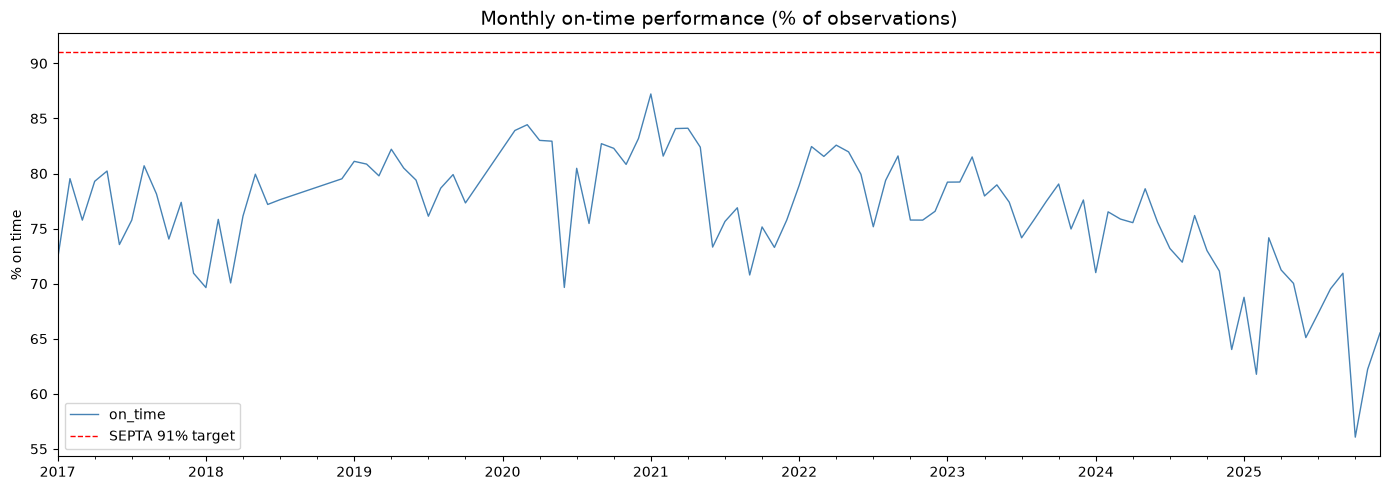

In [9]:
# Monthly OTP rate: % of observations where train was within 6 min
df_valid["year_month"] = df_valid["service_date"].dt.to_period("M") # get month
df_valid["on_time"] = df_valid["lateness"] < 6  # SEPTA threshold

monthly_otp = df_valid.groupby("year_month")["on_time"].mean() * 100

fig, ax = plt.subplots(figsize = (14, 5))
monthly_otp.plot(ax = ax, linewidth = 1, color = "steelblue")
ax.axhline(91, color = "red", linestyle = "--", linewidth = 1, label = "SEPTA 91% target")
ax.set_title("Monthly on-time performance (% of observations)", fontsize = 14)
ax.set_ylabel("% on time")
ax.set_xlabel("")
ax.legend()
plt.tight_layout()
plt.show()

## Train-level Analysis (block_id)

A single value of GTFS's `block_id` can cover two different `line`s back to back (multi-run trip through Center City w/ no layover). Grouping by
`train_number` alone blends those separate runs on separate lines together. The real unit of observation for a single train run on a single line is `(train_number, line)`, confirmed below.

In [10]:
# how common are these multi-line runs through CC
lines_per_train = df_valid.groupby("train_number")["line"].nunique()
multi_line_share = (lines_per_train > 1).mean()

day_lines = df_valid.groupby(["train_number", "service_date"])["line"].nunique()
multi_line_day_share = (day_lines > 1).mean()

print(f"Share of train_number values ever seen on >1 Line: {multi_line_share*100:.1f}%")
print(f"Share of (train_number, service_date) combos spanning >1 Line: {multi_line_day_share*100:.1f}%")

Share of train_number values ever seen on >1 Line: 45.9%
Share of (train_number, service_date) combos spanning >1 Line: 54.2%


In [11]:
# average lateness by (train_number, line) leg and days_active
block_leg_stats = (
    df_valid
    .groupby(["train_number", "line"])
    .agg(
        avg_lateness = ("lateness", "mean"),
        observations = ("lateness", "count"),
        days_active = ("service_date", "nunique"),
        first_seen = ("service_date", "min"),
        last_seen = ("service_date", "max"),
    )
    .query("observations >= 500")
    .sort_values("avg_lateness", ascending = False)
)
block_leg_stats["date_span_days"] = (block_leg_stats["last_seen"] - block_leg_stats["first_seen"]).dt.days

print("10 latest train/line legs:")
print(block_leg_stats.head(10).to_string())
print()
print("10 most punctual train/line legs:")
print(block_leg_stats.tail(10).to_string())

10 latest train/line legs:
                                 avg_lateness  observations  days_active first_seen  last_seen  date_span_days
train_number line                                                                                             
2267         Wilmington/Newark      46.837736          1060           25 2023-07-24 2023-08-25              32
2260         Wilmington/Newark      46.285456          1107           25 2023-07-24 2023-08-25              32
2259         Wilmington/Newark      42.011212          1427           25 2023-07-24 2023-08-25              32
1856         Chestnut Hill West     33.849481           578           27 2025-06-15 2025-09-13              90
2264         Wilmington/Newark      33.809984           621           25 2023-07-24 2023-08-25              32
2228         Wilmington/Newark      32.138958           806           46 2022-07-09 2023-08-26             413
2235         Wilmington/Newark      27.964935          1540           46 2022-07-09 2

The "10 latest" legs above are almost all short-term Wilmington/Newark
blocks -- each one was only active for 25-46 days vs. 10k++ for consistent blocks, and they all appear around 2023 or sporadically which suggests there were service disruptions or outlier patterns around that time on the line.

In [12]:
# does a multi-line through-run have worse lateness on avg
multi_line_trains = lines_per_train[lines_per_train > 1].index
df_valid["is_through_running_block"] = df_valid["train_number"].isin(multi_line_trains)

thru_run_stats = df_valid.groupby("is_through_running_block")["lateness"].agg(
    avg_lateness = "mean",
    otp_rate = lambda x: (x < 6).mean() * 100,
    observations = "count",
)
display(thru_run_stats)

,avg_lateness,otp_rate,observations
is_through_running_block,,,
False,5.536281,75.022222,5108693
True,4.909321,75.347918,15022711


In [13]:
# busiest block, split by leg (line)
highest_n_train = df_valid["train_number"].value_counts().index[0]
print("Block with most observations:", highest_n_train, "\n")

block_df = df_valid[df_valid["train_number"] == highest_n_train].copy()
print(block_df["line"].value_counts())

Block with most observations: 514 



line
Lansdale/Doylestown    50497
Paoli/Thorndale        29713
Name: count, dtype: int64


In [14]:
# does lateness carry over through handoffs on this line
train514 = df_valid[df_valid["train_number"] == "514"].copy()
train514["_time_sec"] = pd.to_timedelta(train514["time"]).dt.total_seconds()
train514 = train514.sort_values(["service_date", "_time_sec"])

train514["prev_line"] = train514.groupby("service_date")["line"].shift(1)
train514["prev_lateness"] = train514.groupby("service_date")["lateness"].shift(1)
train514["line_changed"] = (
    train514["line"].notna()
    & train514["prev_line"].notna()
    & (train514["line"] != train514["prev_line"])
)

handoffs = train514.loc[
    train514["line_changed"],
    ["service_date", "prev_line", "line", "prev_lateness", "lateness"],
].rename(columns = {"line": "next_line", "lateness": "next_lateness"})

print(f"{len(handoffs):,} same-day handoffs (block 514)")
print(f"corr(prev_lateness, next_lateness) = {handoffs['prev_lateness'].corr(handoffs['next_lateness']):.2f}")

2,028 same-day handoffs (block 514)
corr(prev_lateness, next_lateness) = 0.55


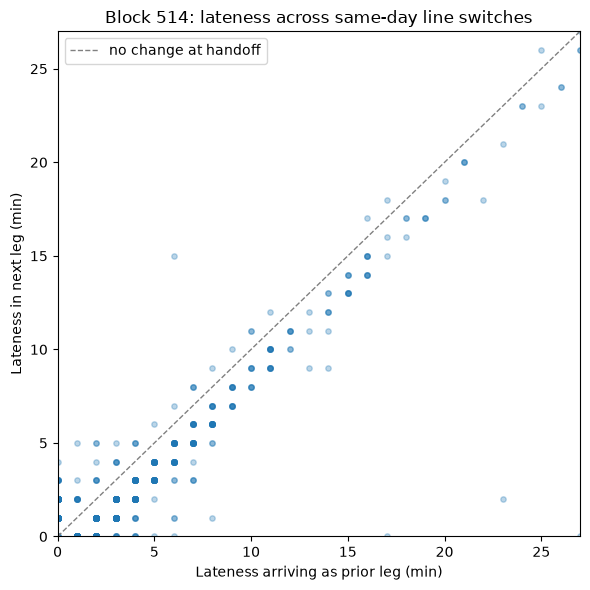

In [15]:
fig, ax = plt.subplots(figsize = (6, 6))
ax.scatter(handoffs["prev_lateness"], handoffs["next_lateness"],
           alpha = 0.3, s = 15)

lim = max(handoffs["prev_lateness"].quantile(0.99), 
          handoffs["next_lateness"].quantile(0.99))
ax.plot([0, lim], [0, lim], 
        color = "gray", 
        linestyle = "--", 
        linewidth = 1, 
        label = "no change at handoff")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Lateness arriving as prior leg (min)")
ax.set_ylabel("Lateness in next leg (min)")
ax.set_title("Block 514: lateness across same-day line switches")
ax.legend()
plt.tight_layout()
plt.show()

We see that a late arrival on the first leg of a trip in this same-day multi-line block (our most commonly observed block_id) pretty consistently predicts lateness in the next leg, even if trains tend to make up a minute or two.

## Time of Day Analysis

In [16]:
# Note: service_date is not the same as actual date
# Septa service date starts at 3 AM and runs til 3 AM
# the following day, so all trains running between midnight
# and 2:59 are actually running on the next calendar day

df_latenight =df_valid[df_valid["time"] < "03:00:00"]
print(f"Service date != Actual date observations: {len(df_latenight):,}")
df_latenight.head()

Service date != Actual date observations: 328,663


,service_date,time,train_number,lateness,datetime,year,month,day_of_week,period_flag,line,...,sched_origin_sec,sched_terminus_sec,sched_duration_sec,n_scheduled_stops,origin_stop_id,terminus_stop_id,lateness_bucket,year_month,on_time,is_through_running_block
0,2017-01-01,00:00:00,3540,25,2017-01-02 00:00:00,2017,1,Sunday,normal,Lansdale/Doylestown,...,79680.0,85080.0,5400.0,28.0,90406,90538,20+ min,2017-01,False,True
1,2017-01-01,00:00:00,3542,1,2017-01-02 00:00:00,2017,1,Sunday,normal,Lansdale/Doylestown,...,83280.0,88680.0,5400.0,28.0,90406,90538,0–2 min,2017-01,True,True
2,2017-01-01,00:00:00,5368,0,2017-01-02 00:00:00,2017,1,Sunday,normal,Paoli/Thorndale,...,83820.0,86520.0,2700.0,19.0,90505,90004,Early,2017-01,True,True
3,2017-01-01,00:02:00,3540,23,2017-01-02 00:02:00,2017,1,Sunday,normal,Lansdale/Doylestown,...,79680.0,85080.0,5400.0,28.0,90406,90538,20+ min,2017-01,False,True
4,2017-01-01,00:02:00,9740,0,2017-01-02 00:02:00,2017,1,Sunday,normal,Trenton,...,86460.0,90000.0,3540.0,14.0,90701,90007,Early,2017-01,True,False


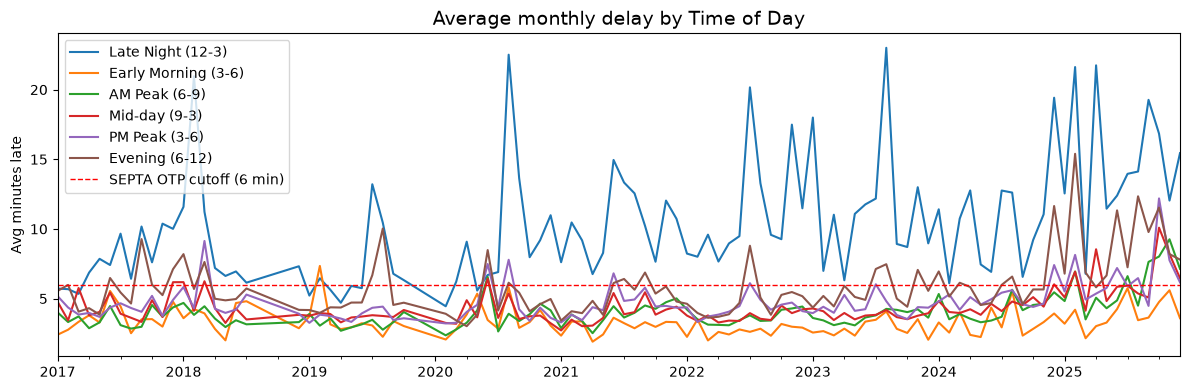

,avg_delay,otp_pct,n
time_of_day,,,
Late Night (12-3),10.6,63.0,328398
Early Morning (3-6),3.4,86.6,651518
AM Peak (6-9),4.2,78.0,3786029
Mid-day (9-3),4.5,76.7,5926594
PM Peak (3-6),4.9,74.1,4029527
Evening (6-12),6.2,72.1,5408965


In [17]:
# Check OTP by time of day

# AM/PM peak edges match PEAK_WINDOWS_SEC in 07_reduce_for_modeling.ipynb (am_peak 6-9, pm_peak 15-18)
time_bins = ["00:00:00", "03:00:00", "06:00:00", "09:00:00",
             "15:00:00", "18:00:00", "23:59:59"]
time_labels = ["Late Night (12-3)", "Early Morning (3-6)", "AM Peak (6-9)",
               "Mid-day (9-3)", "PM Peak (3-6)", "Evening (6-12)"]

df_valid["time_of_day"] = pd.cut(df_valid["time"],
                                 bins = time_bins,
                                 labels = time_labels)

df_valid["year_month"] = df_valid["service_date"].dt.to_period("M")

monthly_tod = (
    df_valid
    .groupby(["year_month", "time_of_day"], observed = True)["lateness"]
    .mean()
    .unstack("time_of_day"))

fig, ax = plt.subplots(figsize = (12, 4))
monthly_tod.plot(ax = ax,
             linewidth = 1.5)
ax.set_title(f"Average monthly delay by Time of Day", fontsize = 14)
ax.set_ylabel("Avg minutes late")
ax.set_xlabel("")
ax.axhline(6,
           color = "red",
           linestyle = "--",
           linewidth = 1,
           label = "SEPTA OTP cutoff (6 min)")

ax.legend()
plt.tight_layout()
plt.show()

# Summary statistics for each period
time_of_day_stats = (
    df_valid
    .groupby("time_of_day", observed = True)["lateness"]
    .agg(
        avg_delay = "mean",
        otp_pct = lambda x: (x < 6).mean() * 100,
        n = "count",
    )
    .reindex(time_labels)
    .round(1)
)
display(time_of_day_stats)

# Line-level Analysis

In [18]:
# excludes 113 rows of "Center City Only Trains"
# bc not a real line
df_lines = df_valid[df_valid["line"] != "Center City Only Trains"]

In [19]:
# Average lateness and OTP rate by line
line_stats = (
    df_lines[df_lines["period_flag"] == "normal"]
    .groupby("line")["lateness"]
    .agg(
        otp_rate = lambda x: (x < 6).mean() * 100,
        avg_lateness = "mean",
        observations = "count"
    )
    .sort_values("otp_rate", ascending = True)
    .round(2)
)
display(line_stats) # worst -> best (lowest -> highest on-time rate)

,otp_rate,avg_lateness,observations
line,,,
Wilmington/Newark,67.63,6.40,1531598
Paoli/Thorndale,68.59,5.99,2549675
Media/Wawa,73.04,5.69,730169
Lansdale/Doylestown,73.13,5.09,2904090
Trenton,73.21,5.58,1799950
West Trenton,74.76,4.87,1976275
Chestnut Hill West,78.67,4.51,886217
Manayunk/Norristown,79.06,4.36,1482419
Media/Elwyn,79.30,4.40,624863


- At first glance, it does appear that the longest lines have the worst OTP and vice versa. 
- Amtrak sharing might hold up (Paoli, Wilmington, West Trenton), unless it's all attributable to distance.

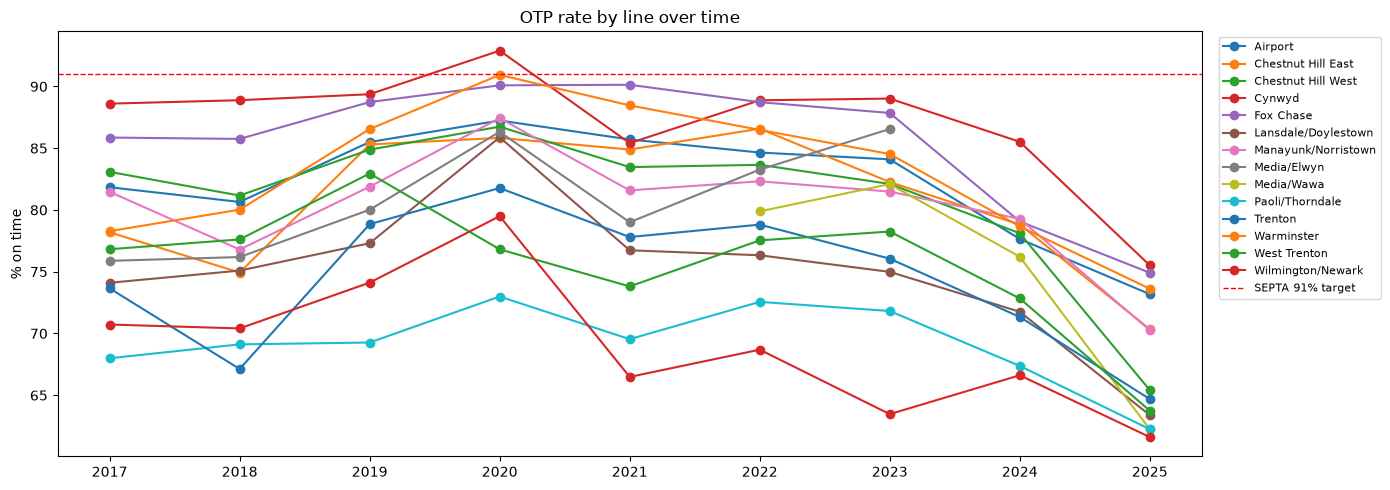

In [20]:
# OTP rate by line over time
line_otp = (
    df_lines[df_lines["period_flag"] == "normal"]
    .groupby(["year", "line"])
    .agg(
        otp_rate = ("lateness", lambda x: (x < 6).mean() *100),
        obs = ("lateness", "count")
    )
    .reset_index()
)

# filter out line-years with weirdly low observations
line_otp = line_otp[line_otp["obs"] >= 1000]

fig, ax = plt.subplots(figsize = (14, 5))
for line, group in line_otp.groupby("line"):
    ax.plot(group["year"], group["otp_rate"], marker = "o", linewidth = 1.5, label = line)
ax.axhline(91, color = "red", linestyle = "--", linewidth = 1, label = "SEPTA 91% target")
ax.set_title("OTP rate by line over time")
ax.set_ylabel("% on time")
ax.set_xlabel("")
ax.legend(bbox_to_anchor = (1.01, 1), loc = "upper left", fontsize = 8)
plt.tight_layout()
plt.show()

Observations:
- Cynwyd is clearly the best-performing line and the only one we've ever seen reach SEPTA's 91% OTP target (in 2020). This makes sense given that it's the shortest + simplest line
- Paoli/Thorndale is consistently one of the lowest performers. 
- 2020 shows a bump across all lines - probably due to decreased service.

- 2024-2025 shows a collapse in OTP across the board. This seems like a pretty clear indicator of systemic stress, likely due to the funding crisis. Dramatic service cuts, fare increases in summer 2024/after pandemic relief funding ended. Aug 2025: 20% service cuts across the board, including RR. Restored a few weeks later after Shapiro approved emergency funding.
Drop likely reflects this decrease + possible system/infrastructure deterioration from continued patchwork funding.

In [21]:
line_time_of_day = (
    df_lines[df_lines["period_flag"] == "normal"]
    .groupby(["line", "time_of_day"], observed = True)["lateness"]
    .mean()
    .unstack("time_of_day")
    .round(2)
)
display(line_time_of_day)

time_of_day,Late Night (12-3),Early Morning (3-6),AM Peak (6-9),Mid-day (9-3),PM Peak (3-6),Evening (6-12)
line,,,,,,
Airport,9.79,2.77,3.64,3.86,4.35,5.27
Chestnut Hill East,6.86,2.62,3.36,3.83,4.15,4.75
Chestnut Hill West,9.91,1.92,3.63,4.12,4.41,5.67
Cynwyd,2.71,6.43,3.12,4.25,3.07,6.32
Fox Chase,37.15,2.52,3.30,3.12,3.87,4.34
Lansdale/Doylestown,9.50,2.38,4.06,4.56,5.13,6.14
Manayunk/Norristown,7.57,2.10,4.04,4.18,4.17,4.84
Media/Elwyn,16.31,2.53,3.31,4.00,3.97,5.41
Media/Wawa,18.63,3.05,4.80,4.72,5.55,6.80
